# Session 6, Notebook 1: Surrogates, the Idea

**Course:** Deep Learning for Solving Dynamic Models, University of Padova, 23-24 September 2026
**Session:** Day 2, 09:00-09:50, Deep surrogates and Gaussian processes
**Slides:** `06_Deep_Surrogates_and_GPs.pdf`
**Author:** Simon Scheidegger (HEC, University of Lausanne)

In [1]:
RUN_MODE = "teaching"  # one of: "smoke", "teaching", "production"
SEED = 0

A **surrogate** is a cheap function that stands in for an expensive one. The expensive one here
is the solution of the stochastic Brock-Mirman model of Session 2 at a given discount factor and
persistence, $(\beta, \varrho)$, computed by a reference method that takes about a second. The
quantity of interest is what the solved model implies, for instance the mean capital stock and the
mean investment share along a long simulation:

$$q(\beta, \varrho) = \big(\, \mathbb{E}[K_t],\ \mathbb{E}[I_t / Y_t] \,\big).$$

Anyone who wants $q$ at a thousand parameter values, an estimator or a sensitivity analysis, pays a
thousand solves. A surrogate pays a few dozen, once, and then answers in microseconds.

| Section | Step |
|:--|:--|
| 1 | The expensive model and the quantity of interest |
| 2 | Design and label: a few dozen solves |
| 3 | Two surrogates on the same labels: a Gaussian process and a small network |
| 4 | More labels: how each surrogate's error falls with the number of solves |
| 5 | What to remember |

Both surrogates are supervised regressions of the same labels. Session 7 builds a different kind
of surrogate, a policy network trained on the model's equations with the parameters as inputs, and
needs no labels at all.

In [2]:
# ----------------------------------------------------------------
# Imports, presets, plot style, the reference solver
# ----------------------------------------------------------------
import sys, time, warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from scipy.stats import qmc
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern
from sklearn.exceptions import ConvergenceWarning
import torch
import torch.nn as nn

sys.path.insert(0, "..")
import brock_mirman_reference as bm

warnings.filterwarnings("ignore", category=ConvergenceWarning)   # the marginal-likelihood optimizer's stop reports
warnings.filterwarnings("ignore", message="The balance properties of Sobol")   # 60 test points is not a power of two
torch.set_num_threads(2)
torch.manual_seed(SEED)
rng = np.random.default_rng(SEED)

rcParams.update({"figure.dpi": 120, "font.size": 11, "axes.titlesize": 12, "axes.labelsize": 11,
                 "legend.fontsize": 10, "font.family": "serif", "mathtext.fontset": "cm",
                 "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.25})
C_GP, C_NN, C_REF = "#2a9d8f", "#e76f51", "#264653"

FIG_DIR   = Path("..") / ".." / "slides" / "figures"
SAVE_FIGS = (RUN_MODE == "teaching")
def savefig(fig, name):
    if SAVE_FIGS:
        FIG_DIR.mkdir(parents=True, exist_ok=True)
        fig.savefig(FIG_DIR / f"{name}.pdf", bbox_inches="tight")

N_LABELS = {"smoke": [10, 20, 40], "teaching": [10, 20, 40, 80, 160], "production": [10, 20, 40, 80, 160, 320]}[RUN_MODE]
N_TEST   = {"smoke": 20, "teaching": 60, "production": 150}[RUN_MODE]
T_NOTEBOOK = time.perf_counter()
print(f"RUN_MODE = {RUN_MODE}: label budgets {N_LABELS}, {N_TEST} test solves")

RUN_MODE = teaching: label budgets [10, 20, 40, 80, 160], 60 test solves


---
## 1. The expensive model and the quantity of interest

`brock_mirman_reference.solve(beta, rho)` iterates on the Euler equation until the consumption
function stops changing (endogenous grid method, cubic splines). One call is the unit of cost in
this notebook. The quantity of interest is computed from a simulation of 2,000 periods under a
fixed shock sequence, so that $q$ is a deterministic, smooth function of $(\beta, \varrho)$.

In [3]:
BOX_LO, BOX_HI = np.array([0.92, 0.50]), np.array([0.99, 0.99])     # (beta, rho)
QOI_NAMES = ["mean capital", "mean investment share"]

def qoi(theta, T=2000, seed=11):
    """The expensive map: solve the model at theta = (beta, rho), simulate, take two means."""
    beta, rho = theta
    pol = bm.solve(beta, rho)
    Y, C, K = bm.simulate(pol, beta, rho, T=T, seed=seed)
    return np.array([K.mean(), 1.0 - (C / Y).mean()])

t0 = time.perf_counter()
q0 = qoi([0.96, 0.90])
t_solve = time.perf_counter() - t0
print(f"q(0.96, 0.90) = ({q0[0]:.4f}, {q0[1]:.4f}) in {t_solve:.2f} s")
print(f"a 30 x 30 grid over the box would cost {900 * t_solve / 60:.0f} minutes")

q(0.96, 0.90) = (4.3734, 0.2533) in 1.25 s
a 30 x 30 grid over the box would cost 19 minutes


---
## 2. Design and label

A Latin hypercube design spreads the solves over the box; the largest budget is computed once and
the smaller budgets are its first rows. A separate set of test points, drawn at random, is used
only to measure errors. Every label is one call to the reference solver.

In [4]:
N_MAX = max(N_LABELS)
theta_design = qmc.scale(qmc.LatinHypercube(d=2, seed=SEED).random(N_MAX), BOX_LO, BOX_HI)
theta_test   = qmc.scale(qmc.Sobol(d=2, seed=SEED + 1).random(N_TEST), BOX_LO, BOX_HI)

t0 = time.perf_counter()
q_design = np.array([qoi(th) for th in theta_design])
q_test   = np.array([qoi(th) for th in theta_test])
print(f"{N_MAX + N_TEST} solves in {time.perf_counter()-t0:.0f} s")
np.savez("qoi_design.npz", theta_design=theta_design, q_design=q_design, theta_test=theta_test, q_test=q_test)

for j, name in enumerate(QOI_NAMES):
    print(f"{name:<22s} ranges over [{q_design[:, j].min():.4f}, {q_design[:, j].max():.4f}] on the design")

220 solves in 307 s
mean capital           ranges over [2.8103, 6.4761] on the design
mean investment share  ranges over [0.1919, 0.3261] on the design


---
## 3. Two surrogates on the same labels

Both map the scaled inputs $u = (\theta - \theta_{\rm lo}) / (\theta_{\rm hi} - \theta_{\rm lo}) \in [0,1]^2$
to the standardized outputs, one model per quantity of interest.

* **Gaussian process**: Matérn 5/2 kernel with one length scale per input, hyperparameters by
  marginal likelihood, a jitter of $10^{-8}$ on the diagonal. The posterior mean is the prediction;
  the posterior standard deviation is an error bar.
* **Network**: a $2 \times 32$ tanh multilayer perceptron, Adam on the full batch, 3,000 epochs.
  A prediction, no error bar.

Same 40 labels, same test points, same error metric: absolute error divided by the range of the
quantity on the design.

In [5]:
scale_in  = lambda th: (np.asarray(th) - BOX_LO) / (BOX_HI - BOX_LO)


class GPSurrogate:
    def __init__(self):
        self.models = []
    def fit(self, theta, q):
        self.mu, self.sd = q.mean(0), q.std(0)
        self.models = [GaussianProcessRegressor(ConstantKernel(1.0) * Matern(length_scale=[0.3, 0.3], nu=2.5),
                                                alpha=1e-8, normalize_y=False, n_restarts_optimizer=3, random_state=SEED)
                       .fit(scale_in(theta), (q[:, j] - self.mu[j]) / self.sd[j]) for j in range(q.shape[1])]
        return self
    def predict(self, theta, return_std=False):
        out = [m.predict(scale_in(theta), return_std=True) for m in self.models]
        mean = np.column_stack([o[0] for o in out]) * self.sd + self.mu
        std  = np.column_stack([o[1] for o in out]) * self.sd
        return (mean, std) if return_std else mean
    def length_scales(self):
        return np.array([m.kernel_.k2.length_scale for m in self.models])


class NNSurrogate:
    def __init__(self, width=32, epochs=3000, lr=1e-2):
        self.width, self.epochs, self.lr = width, epochs, lr
    def fit(self, theta, q):
        self.mu, self.sd = q.mean(0), q.std(0)
        X = torch.tensor(scale_in(theta), dtype=torch.float32)
        Y = torch.tensor((q - self.mu) / self.sd, dtype=torch.float32)
        torch.manual_seed(SEED)
        self.net = nn.Sequential(nn.Linear(2, self.width), nn.Tanh(), nn.Linear(self.width, self.width), nn.Tanh(),
                                 nn.Linear(self.width, q.shape[1]))
        opt = torch.optim.Adam(self.net.parameters(), lr=self.lr)
        sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=self.epochs, eta_min=1e-4)
        for _ in range(self.epochs):
            loss = torch.mean((self.net(X) - Y)**2)
            opt.zero_grad(); loss.backward(); opt.step(); sched.step()
        return self
    def predict(self, theta):
        with torch.no_grad():
            return self.net(torch.tensor(scale_in(theta), dtype=torch.float32)).numpy() * self.sd + self.mu


q_range = q_design.max(0) - q_design.min(0)
def errors(pred, truth):
    """Relative to the range of each quantity on the design: mean and max over the test points."""
    e = np.abs(pred - truth) / q_range
    return e.mean(0), e.max(0)

N0 = 40
t0 = time.perf_counter(); gp = GPSurrogate().fit(theta_design[:N0], q_design[:N0]); t_gp = time.perf_counter() - t0
t0 = time.perf_counter(); nn_ = NNSurrogate().fit(theta_design[:N0], q_design[:N0]); t_nn = time.perf_counter() - t0
gp_mean, gp_std = gp.predict(theta_test, return_std=True)
nn_mean = nn_.predict(theta_test)
print(f"{N0} labels, {N_TEST} test points; fit time GP {t_gp:.1f} s, network {t_nn:.1f} s\n")
print(f"{'':<22s} {'GP mean':>8s} {'GP max':>8s} {'NN mean':>8s} {'NN max':>8s}   (errors relative to the range)")
for j, name in enumerate(QOI_NAMES):
    eg, en = errors(gp_mean, q_test), errors(nn_mean, q_test)
    print(f"{name:<22s} {eg[0][j]:>8.1e} {eg[1][j]:>8.1e} {en[0][j]:>8.1e} {en[1][j]:>8.1e}")
cover = np.mean(np.abs(gp_mean - q_test) <= 1.96 * gp_std, axis=0)
print(f"\nGP 95% band covers the truth at {100*cover[0]:.0f}% / {100*cover[1]:.0f}% of the test points; "
      f"length scales (beta, rho) in box units: {gp.length_scales()[0].round(2)}, {gp.length_scales()[1].round(2)}")

40 labels, 60 test points; fit time GP 0.5 s, network 3.2 s

                        GP mean   GP max  NN mean   NN max   (errors relative to the range)
mean capital            1.1e-03  2.7e-02  3.9e-03  5.2e-02
mean investment share   5.9e-05  5.5e-04  5.5e-04  3.0e-03

GP 95% band covers the truth at 92% / 97% of the test points; length scales (beta, rho) in box units: [8.57 5.36], [11.96 36.76]


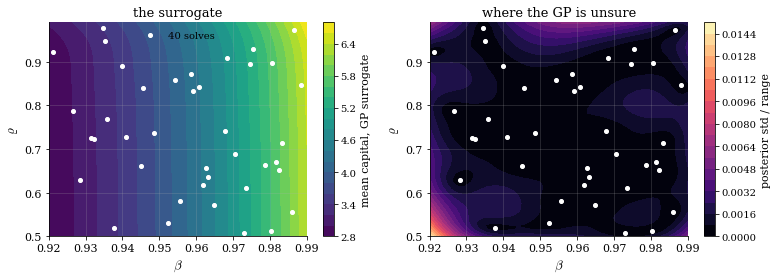

In [6]:
# The surrogate surface, the design, and where the errors are.
u1, u2 = np.meshgrid(np.linspace(0, 1, 60), np.linspace(0, 1, 60))
theta_fine = np.column_stack([u1.ravel(), u2.ravel()]) * (BOX_HI - BOX_LO) + BOX_LO
q_fine, s_fine = gp.predict(theta_fine, return_std=True)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.0))
cs = axes[0].contourf(theta_fine[:, 0].reshape(60, 60), theta_fine[:, 1].reshape(60, 60), q_fine[:, 0].reshape(60, 60), levels=20, cmap="viridis")
axes[0].plot(theta_design[:N0, 0], theta_design[:N0, 1], "o", color="white", ms=4, label=f"{N0} solves")
plt.colorbar(cs, ax=axes[0], label="mean capital, GP surrogate"); axes[0].set_title("the surrogate", fontsize=13); axes[0].legend(frameon=False, fontsize=10)
cs = axes[1].contourf(theta_fine[:, 0].reshape(60, 60), theta_fine[:, 1].reshape(60, 60), s_fine[:, 0].reshape(60, 60) / q_range[0], levels=20, cmap="magma")
axes[1].plot(theta_design[:N0, 0], theta_design[:N0, 1], "o", color="white", ms=4)
plt.colorbar(cs, ax=axes[1], label="posterior std / range"); axes[1].set_title("where the GP is unsure", fontsize=13)
for ax in axes:
    ax.set_xlabel(r"$\beta$", fontsize=13); ax.set_ylabel(r"$\varrho$", fontsize=13); ax.tick_params(labelsize=11)
fig.tight_layout(); savefig(fig, "surrogate_primer_surface"); plt.show()

---
## 4. More labels

The same two surrogates at every budget in the list, on the same test points. The GP's band
coverage is reported alongside: an error bar is only useful if it is calibrated.

N =  10: GP mean 6.4e-03 / 1.2e-03   NN mean 7.4e-03 / 7.0e-03   GP band coverage 73% / 78%   (mean capital / investment share)


N =  20: GP mean 2.9e-03 / 1.9e-04   NN mean 4.1e-03 / 1.4e-03   GP band coverage 73% / 67%   (mean capital / investment share)


N =  40: GP mean 1.1e-03 / 5.9e-05   NN mean 3.9e-03 / 5.5e-04   GP band coverage 92% / 97%   (mean capital / investment share)


N =  80: GP mean 6.4e-04 / 2.6e-05   NN mean 3.6e-03 / 4.1e-04   GP band coverage 93% / 95%   (mean capital / investment share)


N = 160: GP mean 9.9e-05 / 8.2e-06   NN mean 3.0e-03 / 6.0e-04   GP band coverage 97% / 98%   (mean capital / investment share)


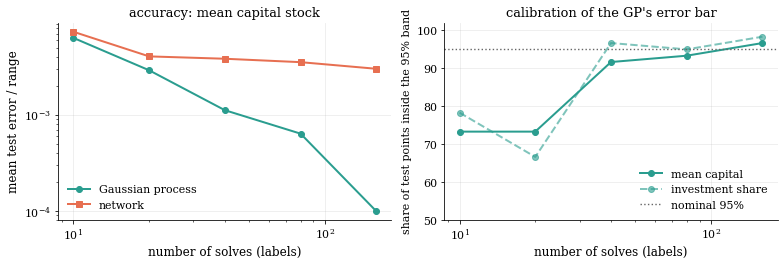

In [7]:
rows = []
for N in N_LABELS:
    gp_N = GPSurrogate().fit(theta_design[:N], q_design[:N])
    nn_N = NNSurrogate().fit(theta_design[:N], q_design[:N])
    mg, sg = gp_N.predict(theta_test, return_std=True)
    mn = nn_N.predict(theta_test)
    eg, en = errors(mg, q_test), errors(mn, q_test)
    cov = np.mean(np.abs(mg - q_test) <= 1.96 * sg, axis=0)
    rows.append((N, eg[0], eg[1], en[0], en[1], cov))
    print(f"N = {N:>3d}: GP mean {eg[0][0]:.1e} / {eg[0][1]:.1e}   NN mean {en[0][0]:.1e} / {en[0][1]:.1e}   "
          f"GP band coverage {100*cov[0]:.0f}% / {100*cov[1]:.0f}%   (mean capital / investment share)")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
Ns = [r[0] for r in rows]
ax = axes[0]
ax.loglog(Ns, [r[1][0] for r in rows], "o-", color=C_GP, lw=2, ms=6, label="Gaussian process")
ax.loglog(Ns, [r[3][0] for r in rows], "s-", color=C_NN, lw=2, ms=6, label="network")
ax.set_xlabel("number of solves (labels)", fontsize=12); ax.set_ylabel("mean test error / range", fontsize=12)
ax.set_title("accuracy: mean capital stock", fontsize=13); ax.legend(frameon=False, fontsize=11); ax.tick_params(labelsize=11)
ax = axes[1]
ax.semilogx(Ns, [100 * r[5][0] for r in rows], "o-", color=C_GP, lw=2, ms=6, label="mean capital")
ax.semilogx(Ns, [100 * r[5][1] for r in rows], "o--", color=C_GP, lw=2, ms=6, alpha=0.6, label="investment share")
ax.axhline(95, color="0.4", ls=":", lw=1.4, label="nominal 95%")
ax.set_ylim(50, 102); ax.set_xlabel("number of solves (labels)", fontsize=12); ax.set_ylabel("share of test points inside the 95% band", fontsize=11)
ax.set_title("calibration of the GP's error bar", fontsize=13); ax.legend(frameon=False, fontsize=11, loc="lower right"); ax.tick_params(labelsize=11)
fig.tight_layout(); savefig(fig, "surrogate_primer_error_vs_n"); plt.show()

---
## 5. What to remember

1. **A surrogate turns solves into function evaluations.** Forty solves, and $q$ is available
   anywhere in the box for the cost of a matrix product. The expensive step is the labelling, and
   it happens once.
2. **The two surrogates learn the same labels.** A Gaussian process and a network are two
   approximators for one regression. The label budget decides between them: with a few dozen
   labels the GP is the accurate one and its error bar is calibrated; with thousands of labels the
   network scales and the GP's $O(N^3)$ fit does not. Read the table above rather than the folklore.
3. **Only one of them says where it is unsure.** The GP's posterior standard deviation is a map of
   its own ignorance, which is what lets one place the next solve well (Notebook 2). A network
   gives a number and no warning.
4. **Labels are not the only way to build a surrogate.** Session 7 trains a policy network on the
   model's Euler equation with $(\beta, \varrho)$ as inputs: no solves, no labels, and the surrogate
   is the solution itself rather than a summary of it.

In [8]:
print(f"RUN_MODE = {RUN_MODE}; notebook wall-clock {time.perf_counter()-T_NOTEBOOK:.0f} s")

RUN_MODE = teaching; notebook wall-clock 331 s
